In [65]:
import os
import operator
from typing import TypedDict, Annotated, Literal, Type
from typing import Optional
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import google.genai as genai
from google.genai import types
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver


In [66]:
load_dotenv()
api_key = os.environ.get("GOOGLE_API_KEY")
if not api_key:
    raise RuntimeError("Please set GOOGLE_API_KEY in your environment or .env file.")
client = genai.Client(api_key=api_key)
MODEL_ID = 'gemini-2.5-flash'

In [67]:
class EvaluationSchema(BaseModel):
    messages: str = Field(description='you are smart ai')

In [68]:
def get_structured_evaluation(prompt: str) -> EvaluationSchema:
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=EvaluationSchema,
        ),
    )
    # Parse the valid JSON text directly back into your Pydantic schema
    return EvaluationSchema.model_validate_json(response.text)

In [69]:
from langgraph.graph.message import add_messages
class chatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages] #add_messages yaha pe reducer function krtrah kaam kr raha hai and BaseMessage se hum define kr pa rahe hai ai_messages,human_messages,sysem_messages hume seprately nhi likhna pad raha hai

In [70]:
def chat_node(state:chatState):
    # take user input
    messages = state['messages']
    # build a text prompt from incoming messages
    if isinstance(messages, list):
        prompt = "\n".join(m.content for m in messages if hasattr(m, 'content'))
    else:
        prompt = str(messages)
    # send to llm and parse structured evaluation
    eval_result = get_structured_evaluation(prompt)
    # return as an AI message so the workflow can continue
    from langchain_core.messages import AIMessage
    return {'messages':[AIMessage(content=eval_result.messages)]}


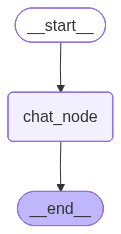

In [71]:
checkpoint = MemorySaver()
graph = StateGraph(chatState)
# add node 
graph.add_node('chat_node',chat_node)
# add edge 
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)
# complile
workflow = graph.compile(checkpointer=checkpoint)
workflow

In [72]:
thread_id = "thread_12345"
initial_state = {'messages': []}

while True:
    user_input = input("hey nice to meet you what you want today: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Exiting the chat.")
        break

    config = {"configurable": {"thread_id": thread_id}}

    # Append the user's message to the existing conversation state
    initial_state['messages'].append(HumanMessage(content=user_input))

    # Invoke the workflow with the updated state and checkpoint config
    result = workflow.invoke(initial_state, config=config)
    initial_state = result

    # Filter out only AI messages from the resulting state
    ai_messages = [m for m in result.get('messages', []) if isinstance(m, AIMessage)]
    ai_only = ai_messages[-1].content if ai_messages else None
    print(f"AI: {ai_only}")


AI: Hello! How can I help you today?
AI: my name is aman
AI: my age is 55
AI: Your name is aman.
AI: The current Prime Minister of India is Narendra Modi.
AI: Your age is 55.
Exiting the chat.


In [74]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='9311e507-2963-471f-a83c-95b823ff6a13'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={}, id='6afa95c0-4571-4d58-906f-2617bd2398bd', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='my name is aman', additional_kwargs={}, response_metadata={}, id='10b25526-6139-4d46-a4e1-a4c1026f1bc7'), AIMessage(content='my name is aman', additional_kwargs={}, response_metadata={}, id='c3153aaa-c1b7-4833-a623-d678bb80f0dd', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='my age is 55', additional_kwargs={}, response_metadata={}, id='9a96f41f-2280-4311-9fa8-d0309424e652'), AIMessage(content='my age is 55', additional_kwargs={}, response_metadata={}, id='949d335e-8885-4402-8d2b-52aeb8a21277', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='88acfe